# 🔍 JobSeeker AI — Retrieval Information System Pipeline

**Tujuan:** Membangun dan membandingkan mesin pencari lowongan kerja menggunakan **TF-IDF (Vector Space Model)** vs **SBERT (Semantic Search)**.

Pipeline ini **TERPISAH** dari ETL Prediction/Modelling. Tidak ada AI Extraction (Gemma) di sini.

## Alur Kerja

```text
Data Mentah (JSON)
      │
      ▼
[1] Filter Heuristik
      │
      ▼
[2] Text Cleaning & STKI
      │
      ▼
[3] TF-IDF Vectorizer
      │
      ▼
[4] SBERT Embedding
      │
      ▼
[5] Evaluasi Model
      │
      ▼
[6] Export
      │
      ▼
[7] Demo Search
```

### [1] Filter Heuristik
Buang spam & data kosong (cepat, tanpa AI)

### [2] Text Cleaning & STKI
Case folding, tokenizing, stopword, stemming

### [3] TF-IDF Vectorizer
Vector Space Model (baseline)

### [4] SBERT Embedding
Semantic vector (paraphrase-multilingual)

### [5] Evaluasi Model
MAP, NDCG@K, Precision@K (12 query)

### [6] Export
Simpan model SBERT + metadata

### [7] Demo Search
Uji cosine similarity kedua model

## Output File

- `backend/data/retrieval/sbert_model_lokal/` — Model SBERT yang sudah di-save
- `backend/data/retrieval/retrieval_metadata.pkl` — Metadata lowongan (title, company, dll)

## Persiapan Lingkungan

> Instalasi pustaka yang diperlukan untuk menjalankan pipeline ini.
> Cell ini tidak perlu dijalankan jika semua dependensi sudah terinstall.

### Instalasi Dependensi Tambahan

Menginstall `ipywidgets` untuk progress bar interaktif dan `PySastrawi` untuk stemming Bahasa Indonesia.

In [1]:
!pip install ipywidgets
!pip install PySastrawi



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1: Import & Konfigurasi

### Import Library

Memuat seluruh library yang digunakan dalam pipeline:
- **pandas, numpy** — Manipulasi data
- **nltk** — Stopwords & tokenization
- **sklearn** — TF-IDF Vectorizer & Cosine Similarity
- **sentence_transformers** — SBERT embedding
- **Sastrawi** — Stemming Bahasa Indonesia
- **matplotlib, seaborn** — Visualisasi

In [2]:
import os
import json
import re
import pickle
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Download NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Step 2: Load Data Mentah

### Konfigurasi Path

Menentukan lokasi file input (data mentah) dan direktori output untuk index & metadata.

In [3]:
# ── Konfigurasi Path ──────────────────────────────────────────────────────────
# Sesuaikan path ini dengan lokasi file raw data Anda
RAW_JOBS_PATH     = "../data/raw/google_jobs_results.json"
OUTPUT_DIR        = "../data/retrieval"
FAISS_INDEX_PATH  = os.path.join(OUTPUT_DIR, "retrieval_index.faiss")
METADATA_PKL_PATH = os.path.join(OUTPUT_DIR, "retrieval_metadata.pkl")

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✅ Konfigurasi selesai.")
print(f"   Input : {RAW_JOBS_PATH}")
print(f"   Output: {OUTPUT_DIR}")

✅ Konfigurasi selesai.
   Input : ../data/raw/google_jobs_results.json
   Output: ../data/retrieval


### Memuat Data Mentah

Membaca file JSON hasil scraping Google Jobs.

In [4]:
with open(RAW_JOBS_PATH, "r", encoding="utf-8") as f:
    raw_jobs = json.load(f)

print(f"✅ Total data dimuat: {len(raw_jobs):,} lowongan")

✅ Total data dimuat: 4,911 lowongan


### Deduplikasi Data

Menghapus lowongan duplikat berdasarkan kombinasi `title` dan `company_name`.

In [5]:
df = pd.DataFrame(raw_jobs)
df_clean = df.drop_duplicates(subset=['title', 'company_name'], keep='first')
print(f"Jumlah data sebelum deduplikasi: {len(df)}")
print(f"Jumlah data setelah deduplikasi: {len(df_clean)}")
df_raw = df_clean.to_dict('records')

Jumlah data sebelum deduplikasi: 4911
Jumlah data setelah deduplikasi: 1868


## Step 3: Heuristic Filter

> **Tujuan:** Buang data yang pasti tidak berguna **sebelum** masuk ke proses embedding yang mahal secara komputasi.
> Tidak ada AI di sini — murni rule-based, sangat cepat.

### Filter Heuristik

Menyaring data sampah (spam, non-job, deskripsi terlalu pendek) menggunakan aturan sederhana tanpa AI:
- Judul atau deskripsi kosong → buang
- Judul terlalu pendek (< 8 karakter) → buang
- Deskripsi terlalu pendek (< 80 karakter) → buang
- Blacklist keyword non-job → buang
- Hanya berisi nomor HP tanpa info kerja → buang

In [6]:
def is_potential_job(title: str, desc: str) -> bool:
    """
    Heuristic filter untuk menyaring data sampah sebelum embedding.
    Return True jika data layak untuk diindeks.
    """
    # 1. Judul atau deskripsi kosong
    if not title or not title.strip():
        return False

    # 2. Judul terlalu pendek
    if len(title.strip()) < 8:
        return False

    # 3. Deskripsi tidak ada atau terlalu pendek
    if not desc or len(desc.strip()) < 80:
        return False

    text = (title + " " + desc).lower()

    # 4. Blacklist konten non-job
    spam_keywords = [
        "resep", "cara memasak", "film sub", "download gratis",
        "berita terkini", "klik link berikut", "info lengkap di link",
        "hubungi wa", "chat wa", "daftar sekarang di link",
        "langsung diterima tanpa", "gaji besar tanpa pengalaman",
        "loker online setiabudi", "loker smk terdekat",
    ]
    if any(k in text for k in spam_keywords):
        return False

    # 5. Deskripsi hanya berisi nomor HP tanpa info kerja yang cukup
    phone_pattern = re.findall(r'\b0\d{8,12}\b', desc)
    if phone_pattern and len(desc.split()) < 30:
        return False

    return True


# Terapkan filter
valid_jobs = [
    job for job in df_raw
    if is_potential_job(job.get("title", ""), job.get("description", ""))
]

rejected_count = len(df_raw) - len(valid_jobs)
print(f"📊 Statistik Filter:")
print(f"   Total raw       : {len(df_raw):,}")
print(f"   Lolos filter    : {len(valid_jobs):,}")
print(f"   Dibuang (spam)  : {rejected_count:,} ({rejected_count/len(df_raw)*100:.1f}%)")

📊 Statistik Filter:
   Total raw       : 1,868
   Lolos filter    : 1,782
   Dibuang (spam)  : 86 (4.6%)


## Step 4: Text Cleaning & Text Representation

> **Tidak menggunakan AI.** Cukup bersihkan HTML/whitespace berlebih, lalu gabungkan 
> `title + company + location + description` menjadi satu teks yang siap di-embed.

### Text Preprocessing STKI

Pipeline preprocessing untuk Information Retrieval:
1. **Case Folding** — ubah ke huruf kecil
2. **Cleaning** — hapus HTML, URL, angka, tanda baca
3. **Tokenization** — pecah kalimat jadi token
4. **Stopword Removal** — buang kata hubung tidak bermakna
5. **Stemming** — ubah kata ke bentuk dasar (PySastrawi)

Teks representasi: gabungan `title + company + location + description`.

In [7]:
# Setup Stemmer & Stopwords
factory = StemmerFactory()
stemmer = factory.create_stemmer()
# Gabungkan stopwords Bahasa Indonesia, Inggris, dan stopword domain (opsional)
STOPWORDS = set(stopwords.words('indonesian')) | set(stopwords.words('english'))
STOPWORDS |= {"lowongan", "kerja", "loker", "posisi", "perusahaan", "dibutuhkan", "candidate", "requirements"}
def preprocess_text_stki(text: str) -> str:
    """
    Teknik Text Preprocessing untuk STKI:
    1. Case Folding: Mengubah teks menjadi huruf kecil
    2. Cleaning: Menghapus HTML, URL, Angka, Tanda Baca
    3. Tokenization: Memecah teks menjadi kata (token)
    4. Stopword Removal: Membuang kata hubung/kata tidak bermakna
    5. Stemming: Mengubah kata ke bentuk dasar menggunakan PySastrawi
    """
    if not text:
        return ""
    
    # 1. Case Folding
    text = text.lower()
    
    # 2. Cleaning
    text = re.sub(r'<[^>]+>', ' ', text)          # Hapus HTML tag
    text = re.sub(r'http\S+|www\S+', ' ', text)   # Hapus URL
    text = re.sub(r'\d+', ' ', text)               # Hapus angka
    text = re.sub(r'[^\w\s]', ' ', text)           # Hapus tanda baca
    text = re.sub(r'\s{2,}', ' ', text).strip()    # Normalisasi spasi
    
    # 3. Tokenization
    tokens = word_tokenize(text)
    
    # 4. Stopword Removal
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    
    # 5. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    
    return " ".join(tokens)
def build_retrieval_text(job: dict) -> str:
    """
    Buat teks representasi dari satu lowongan, lalu lakukan preprocessing STKI.
    Prioritas: title > company > location > description
    """
    title    = job.get("title", "")
    company  = job.get("company_name", "")
    location = job.get("location", "")
    desc     = job.get("description", "")
    
    # Gabungkan semua teks
    raw_text = f"{title} {company} {location} {desc}"
    
    # Lakukan Preprocessing STKI
    clean_str = preprocess_text_stki(raw_text)
    return clean_str
texts = [build_retrieval_text(job) for job in valid_jobs]
# Buat teks representasi untuk semua job yang lolos filter
print("Memulai proses text preprocessing (Case Folding, Tokenization, Stopword, Stemming)...")
print("Proses ini mungkin memakan waktu beberapa menit karena proses stemming.")
texts = [build_retrieval_text(job) for job in valid_jobs]
print(f"✅ Teks preprocessing selesai dibuat: {len(texts):,} item")
print(f"\nContoh teks job pertama setelah preprocessing:")
print(f"  {texts[0][:200]}...")

Memulai proses text preprocessing (Case Folding, Tokenization, Stopword, Stemming)...
Proses ini mungkin memakan waktu beberapa menit karena proses stemming.
✅ Teks preprocessing selesai dibuat: 1,782 item

Contoh teks job pertama setelah preprocessing:
  visual merchandiser hpw jakarta timur forever jakarta timur kota jakarta timur daerah khusus ibukota jakarta buka jakarta timur baru forever visual merchandiser jam jam minggu tanggung tata display pr...


## Step 5: Modeling 

> Melakukan Pemodelan dengan TF-IDF dan SBERT untuk melakukan perbandingan performa retrieval.

## 1. TF-IDF (Vector Space Model)

### Membangun Model TF-IDF

Membuat Vector Space Model menggunakan TF-IDF dengan:
- 10.000 fitur (kata) teratas
- n-gram range (1,2) untuk menangkap frasa

In [8]:
print("Membangun model TF-IDF (Vector Space Model)...")

tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2)
)
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
print(f"✅ TF-IDF Matrix selesai dibuat.")
print(f"   Ukuran Matrix: {tfidf_matrix.shape} (Jumlah Dokumen x Jumlah Fitur/Kata)\n")

Membangun model TF-IDF (Vector Space Model)...
✅ TF-IDF Matrix selesai dibuat.
   Ukuran Matrix: (1782, 10000) (Jumlah Dokumen x Jumlah Fitur/Kata)



### Demo Pencarian TF-IDF

Fungsi `search_tfidf()` untuk menguji kualitas retrieval TF-IDF dengan query contoh.

In [9]:
# 3. Buat fungsi pencarian TF-IDF
def search_tfidf(query: str, top_k: int = 5, threshold: float = 0.01) -> list:
    """
    Fungsi pencarian menggunakan model Vector Space (TF-IDF + Cosine Similarity).
    """
    # a. Preprocessing query user (wajib sama dengan preprocessing dataset)
    clean_query = preprocess_text_stki(query)
    
    # b. Ubah query menjadi vektor TF-IDF
    query_vec = tfidf_vectorizer.transform([clean_query])
    
    # c. Hitung Cosine Similarity antara vektor query dengan seluruh dokumen
    scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    
    # d. Urutkan dan ambil top-k
    top_indices = scores.argsort()[::-1][:top_k]
    
    results = []
    for idx in top_indices:
        score = float(scores[idx])
        if score < threshold:
            continue
            
        # Ambil metadata asli dari valid_jobs untuk ditampilkan
        job = valid_jobs[idx]
        results.append({
            "title": job.get("title", ""),
            "company_name": job.get("company_name", ""),
            "location": job.get("location", ""),
            "similarity_score": round(score, 4),
            "description": job.get("description", "")
        })
        
    return results
# ── Demo Pencarian TF-IDF ──────────────────────────────────────────────────
TEST_QUERY = "Data Analyst Python SQL Jakarta"
print(f"🔍 Pencarian TF-IDF Query: '{TEST_QUERY}'")
print("-" * 70)
tfidf_results = search_tfidf(TEST_QUERY, top_k=3)
for i, r in enumerate(tfidf_results, 1):
    print(f"{i}. [{r['similarity_score']:.3f}] {r['title']}")
    print(f"   🏢 {r['company_name']} | 📍 {r['location']}")
    print()

🔍 Pencarian TF-IDF Query: 'Data Analyst Python SQL Jakarta'
----------------------------------------------------------------------
1. [0.427] ADMIN DATA ANALYST - MAKASSAR
   🏢 Mitracomm Ekasarana | 📍 Makassar, Kota Makassar, Sulawesi Selatan

2. [0.289] Freelance Data Analyst Online Consultant Remote Expert WFH Tangerang
   🏢 Domino's | 📍 Tangerang, Kota Tangerang, Banten

3. [0.288] Data Analyst Supervisor
   🏢 Thamrin Group | 📍 Palembang, Kota Palembang, Sumatera Selatan



## 2. SBERT (Semantic Embedding)

### Konfigurasi Model SBERT

Menggunakan model multilingual `paraphrase-multilingual-MiniLM-L12-v2` yang mendukung Bahasa Indonesia.

In [ ]:
# ── Konfigurasi Model ─────────────────────────────────────────────────────────
# Model multilingual — cocok untuk teks Bahasa Indonesia
SBERT_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
BATCH_SIZE       = 64   
MAX_DESC_CHARS   = 512  


### SBERT Embedding

Mengubah teks lowongan menjadi vektor 384-dimensi menggunakan SBERT.
Proses dilakukan dalam batch untuk efisiensi memori.

In [11]:
print(f"🚀 Memuat model SBERT: '{SBERT_MODEL_NAME}'...")
sbert_model = SentenceTransformer(SBERT_MODEL_NAME)
print(f"✅ Model berhasil dimuat.")
# Buat list teks khusus SBERT (tanpa stemming agar konteks terjaga)
def build_text_sbert(job):
    return f"{job.get('title','')} {job.get('company_name','')} {job.get('location','')} {job.get('description','')}"
sbert_texts = [build_text_sbert(j) for j in valid_jobs]
print(f"\n🔄 Memulai embedding {len(sbert_texts):,} teks dalam batch {BATCH_SIZE}...")
all_embeddings = []
for i in tqdm(range(0, len(sbert_texts), BATCH_SIZE), desc="Encoding Batches"):
    batch = sbert_texts[i : i + BATCH_SIZE]
    vecs  = sbert_model.encode(batch, show_progress_bar=False)
    all_embeddings.append(vecs)
# Simpan ke variabel sbert_matrix agar sinkron dengan fungsi search_sbert
sbert_matrix = np.vstack(all_embeddings).astype("float32")
print(f"\n✅ Embedding selesai!")
print(f"   Shape  : {sbert_matrix.shape}  (jumlah_dokumen × dimensi_vektor)")

🚀 Memuat model SBERT: 'paraphrase-multilingual-MiniLM-L12-v2'...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Model berhasil dimuat.

🔄 Memulai embedding 1,782 teks dalam batch 64...


Encoding Batches:   0%|          | 0/28 [00:00<?, ?it/s]


✅ Embedding selesai!
   Shape  : (1782, 384)  (jumlah_dokumen × dimensi_vektor)


### Fungsi Pencarian

Mendefinisikan dua fungsi pencarian:
- `search_tfidf()` — berbasis TF-IDF + Cosine Similarity
- `search_sbert()` — berbasis SBERT Semantic Embedding + Cosine Similarity

In [12]:
def search_tfidf(query: str, top_k: int = 5, threshold: float = 0.01) -> list:
    clean_q  = preprocess_text_stki(query)
    q_vec    = tfidf_vectorizer.transform([clean_q])
    scores   = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top_idx  = scores.argsort()[::-1][:top_k]
    
    return [
        {**{k: valid_jobs[i].get(k, '') for k in ['title', 'company_name', 'location']},
         'similarity_score': round(float(scores[i]), 4)}
        for i in top_idx if float(scores[i]) >= threshold
    ]


def search_sbert(query: str, top_k: int = 5, threshold: float = 0.3) -> list:
    q_vec   = sbert_model.encode([query])
    scores  = cosine_similarity(q_vec, sbert_matrix).flatten()
    top_idx = scores.argsort()[::-1][:top_k]
    
    return [
        {**{k: valid_jobs[i].get(k, '') for k in ['title', 'company_name', 'location']},
         'similarity_score': round(float(scores[i]), 4)}
        for i in top_idx if float(scores[i]) >= threshold
    ]


## Step 6: Model Evaluation

> Evaluasi performa kedua model menggunakan metrik Information Retrieval standar.

### Ground Truth Query

12 query uji dengan relevansi manual (judul lowongan yang relevan) untuk evaluasi retrieval.
Relevansi ditentukan berdasarkan kecocokan semantik antara query dan judul job.

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.1  GROUND TRUTH — Anotasi manual untuk 12 query
# ─────────────────────────────────────────────────────────────────────────────

GROUND_TRUTH = {
    "Data Analyst Python SQL": [
        "Data Analyst Officer",
        "Data Analyst Supervisor",
        "ADMIN DATA ANALYST - MAKASSAR",
        "Data Analyst",
        "Business Analyst",
    ],
    "Software Engineer React TypeScript": [
        "Software Engineer",
        "Frontend Developer",
        "Full Stack Developer",
        "Web Developer",
        "Software Quality Assurance",
    ],
    "Akuntan laporan keuangan": [
        "Finance Associate",
        "Accounting Staff",
        "Finance Staff",
        "Akuntan",
        "Finance and Accounting Staff",
    ],
    "Operator produksi pabrik": [
        "Production Operator",
        "Operator Production",
        "Operator Pabrik",
        "Produksi Operator",
        "Operator Mesin",
    ],
    "Marketing digital media sosial": [
        "Social Media Strategist",
        "Digital Marketing",
        "Marketing Staff",
        "Social Media Specialist",
        "Content Creator",
    ],
    "HRD Rekrutmen Personalia": [
        "HR Recruiter",
        "HRD Staff",
        "Human Resources",
        "Recruitment Staff",
        "HR Generalist",
    ],
    "lowongan teknisi anak sma": [
        "Teknisi Listrik",
        "Electrical Technician",
        "Teknisi",
        "Electrician",
        "Maintenance Technician",
    ],
    "kerja remote admin data entry": [
        "Admin",
        "Data Entry",
        "Administrasi",
        "Admin Data",
        "Staff Admin",
    ],
    "part time barista cafe mahasiswa": [
        "Barista",
        "Waiter",
        "Pramusaji",
        "Crew Store",
        "Server",
    ],
    "fresh graduate management trainee": [
        "Management Trainee",
        "MT",
        "Officer Development Program",
        "ODP",
        "Trainee",
    ],
    "sopir pengiriman barang logistik": [
        "Driver",
        "Pengemudi",
        "Sopir",
        "Kurir",
        "Logistik Driver",
    ],
    "desain grafis bisa pakai canva": [
        "Graphic Designer",
        "Desainer Grafis",
        "UI/UX Designer",
        "Visual Designer",
        "Creative Designer",
    ],
}

TOP_K = 5  # Evaluasi pada top-5 hasil
print(f"✅ Ground truth siap: {len(GROUND_TRUTH)} query, evaluasi pada top-{TOP_K}")

✅ Ground truth siap: 12 query, evaluasi pada top-5


### Fungsi Metrik Evaluasi

Implementasi metrik evaluasi Information Retrieval:
- **Precision@K** — proporsi relevan dalam top-K
- **Average Precision (AP)** — presisi rata-rata di setiap posisi relevan
- **NDCG@K** — Normalized Discounted Cumulative Gain

In [14]:
def is_relevant(title: str, relevant_titles: list[str]) -> bool:
    """Cek apakah judul hasil pencarian relevan (partial match, case-insensitive)."""
    title_lower = title.lower()
    return any(rel.lower() in title_lower or title_lower in rel.lower()
               for rel in relevant_titles)


def precision_at_k(retrieved: list[str], relevant: list[str], k: int = 5) -> float:
    """
    Precision@K = (jumlah relevan dalam top-K) / K
    """
    top_k = retrieved[:k]
    hits = sum(1 for t in top_k if is_relevant(t, relevant))
    return hits / k if k > 0 else 0.0


def average_precision(retrieved: list[str], relevant: list[str]) -> float:
    """
    Average Precision (AP) untuk satu query.
    AP = rata-rata precision di setiap posisi di mana item relevan ditemukan.
    """
    hits = 0
    score = 0.0
    for i, title in enumerate(retrieved, start=1):
        if is_relevant(title, relevant):
            hits += 1
            score += hits / i
    return score / min(len(relevant), len(retrieved)) if retrieved else 0.0


def dcg_at_k(retrieved: list[str], relevant: list[str], k: int = 5) -> float:
    """
    Discounted Cumulative Gain @K
    DCG = Σ rel_i / log2(i+1)  untuk i=1..K
    """
    dcg = 0.0
    for i, title in enumerate(retrieved[:k], start=1):
        rel = 1.0 if is_relevant(title, relevant) else 0.0
        dcg += rel / np.log2(i + 1)
    return dcg


def ndcg_at_k(retrieved: list[str], relevant: list[str], k: int = 5) -> float:
    """
    Normalized DCG @K = DCG@K / IDCG@K
    IDCG = DCG dalam kondisi ideal (semua item relevan di posisi teratas)
    """
    ideal = relevant[:k]  # Ideal: semua relevan di posisi teratas
    idcg = sum(1.0 / np.log2(i + 1) for i in range(1, min(len(ideal), k) + 1))
    if idcg == 0:
        return 0.0
    return dcg_at_k(retrieved, relevant, k) / idcg

### Evaluasi Model

Menjalankan evaluasi TF-IDF dan SBERT terhadap 12 query ground truth.
Menampilkan MAP, NDCG@5, dan Precision@5 untuk kedua model.

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.3  JALANKAN EVALUASI — TF-IDF & SBERT
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_model(search_fn, model_name: str, ground_truth: dict, top_k: int = 5):
    """
    Jalankan evaluasi lengkap untuk satu model retrieval.
    
    Returns dict berisi per-query metrics & agregasi MAP, NDCG, Precision@K.
    """
    results = []

    for query, relevant_titles in ground_truth.items():
        try:
            retrieved_items = search_fn(query, top_k=top_k * 2)  
            retrieved_titles = [r["title"] for r in retrieved_items]
        except Exception as e:
            print(f"  ⚠️  Error pada query '{query}': {e}")
            retrieved_titles = []

        p_k   = precision_at_k(retrieved_titles, relevant_titles, k=top_k)
        ap    = average_precision(retrieved_titles, relevant_titles)
        ndcg  = ndcg_at_k(retrieved_titles, relevant_titles, k=top_k)

        # Confusion matrix per-posisi (binary: relevan / tidak)
        binary_actual    = [1 if is_relevant(t, relevant_titles) else 0
                            for t in retrieved_titles[:top_k]]
        binary_predicted = [1] * len(binary_actual) 

        results.append({
            "query":          query,
            "p_at_k":         p_k,
            "ap":             ap,
            "ndcg":           ndcg,
            "retrieved":      retrieved_titles[:top_k],
            "actual_binary":  binary_actual,
        })

    # Agregasi
    map_score  = np.mean([r["ap"]    for r in results])
    ndcg_score = np.mean([r["ndcg"]  for r in results])
    prec_score = np.mean([r["p_at_k"] for r in results])

    print(f"\n{'='*60}")
    print(f"  📊 Hasil Evaluasi: {model_name}")
    print(f"{'='*60}")
    print(f"  MAP (Mean Average Precision) : {map_score:.4f}")
    print(f"  NDCG@{top_k}                 : {ndcg_score:.4f}")
    print(f"  Precision@{top_k}             : {prec_score:.4f}")
    print(f"{'='*60}")

    print(f"\n  📋 Detail per Query:")
    for r in results:
        print(f"  [{r['p_at_k']:.2f} P@K | {r['ap']:.2f} AP | {r['ndcg']:.2f} NDCG] "
              f"'{r['query']}'")

    return {
        "model":        model_name,
        "map":          map_score,
        "ndcg":         ndcg_score,
        "precision_k":  prec_score,
        "per_query":    results,
    }


# ── Evaluasi TF-IDF ──────────────────────────────────────────────────────────
print("🔄 Evaluasi TF-IDF...")
eval_tfidf = evaluate_model(search_tfidf, "TF-IDF (Vector Space Model)", GROUND_TRUTH, TOP_K)

# ── Evaluasi SBERT ───────────────────────────────────────────────────────────
print("\n🔄 Evaluasi SBERT (Semantic Search)...")
eval_sbert = evaluate_model(search_sbert, "SBERT (paraphrase-multilingual)", GROUND_TRUTH, TOP_K)


🔄 Evaluasi TF-IDF...

  📊 Hasil Evaluasi: TF-IDF (Vector Space Model)
  MAP (Mean Average Precision) : 0.3754
  NDCG@5                 : 0.3259
  Precision@5             : 0.3333

  📋 Detail per Query:
  [0.80 P@K | 0.80 AP | 0.87 NDCG] 'Data Analyst Python SQL'
  [0.20 P@K | 0.10 AP | 0.21 NDCG] 'Software Engineer React TypeScript'
  [0.40 P@K | 0.17 AP | 0.32 NDCG] 'Akuntan laporan keuangan'
  [0.00 P@K | 0.03 AP | 0.00 NDCG] 'Operator produksi pabrik'
  [0.00 P@K | 0.03 AP | 0.00 NDCG] 'Marketing digital media sosial'
  [0.20 P@K | 0.07 AP | 0.17 NDCG] 'HRD Rekrutmen Personalia'
  [0.20 P@K | 0.27 AP | 0.13 NDCG] 'lowongan teknisi anak sma'
  [0.80 P@K | 1.51 AP | 0.79 NDCG] 'kerja remote admin data entry'
  [0.00 P@K | 0.23 AP | 0.00 NDCG] 'part time barista cafe mahasiswa'
  [0.60 P@K | 0.53 AP | 0.64 NDCG] 'fresh graduate management trainee'
  [0.80 P@K | 0.77 AP | 0.79 NDCG] 'sopir pengiriman barang logistik'
  [0.00 P@K | 0.00 AP | 0.00 NDCG] 'desain grafis bisa pakai canva'

🔄

### Confusion Matrix

Visualisasi jumlah hasil relevan vs tidak relevan dari top-K retrieval untuk kedua model.

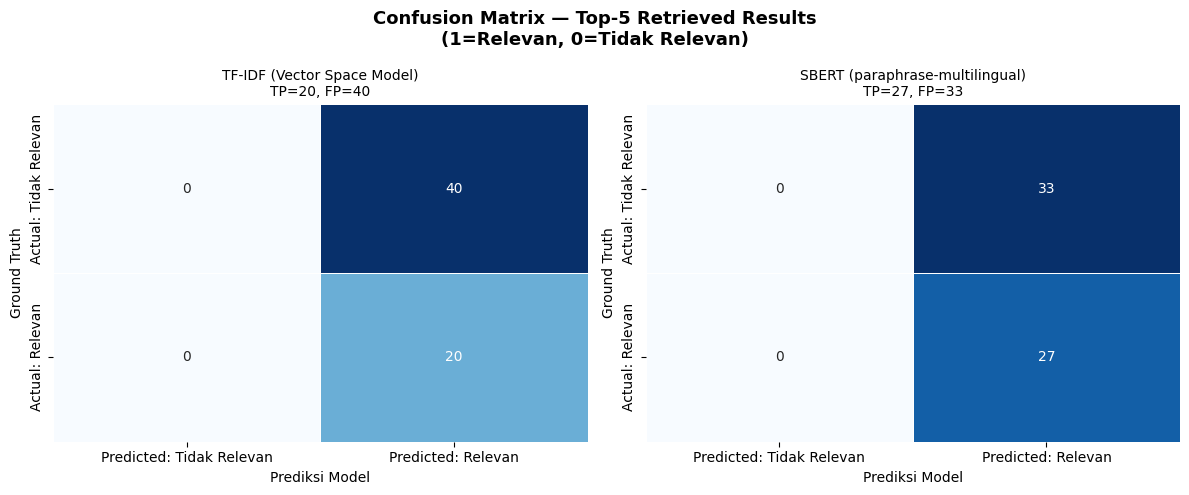

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.4  CONFUSION MATRIX — Agregat semua query
# ─────────────────────────────────────────────────────────────────────────────
# Bangun confusion matrix dari binary relevance (top-K per query)

def build_confusion_data(eval_result: dict):
    """Kumpulkan semua binary label dari seluruh query."""
    y_true, y_pred = [], []
    gt_map = {q: rel for q, rel in GROUND_TRUTH.items()}

    for r in eval_result["per_query"]:
        relevant = gt_map[r["query"]]
        for title in r["retrieved"]:
            y_pred.append(1)  # model selalu mengembalikan sebagai "retrieved"
            y_true.append(1 if is_relevant(title, relevant) else 0)
    return np.array(y_true), np.array(y_pred)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Confusion Matrix — Top-{TOP_K} Retrieved Results\n(1=Relevan, 0=Tidak Relevan)",
             fontsize=13, fontweight="bold")

for ax, eval_res in zip(axes, [eval_tfidf, eval_sbert]):
    y_true, y_pred = build_confusion_data(eval_res)
    
    # Baris confusion_matrix telah dihapus karena tidak dipakai

    # Hitung TP, FP, FN, TN secara manual
    TP = int(np.sum((y_true == 1)))
    FP = int(np.sum((y_true == 0)))
    FN = 0  # tidak bisa dihitung tanpa tahu total relevan di corpus
    TN = 0

    cm_display = np.array([[TN, FP], [FN, TP]])

    import seaborn as sns # Pastikan seaborn diimport
    sns.heatmap(cm_display, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Predicted: Tidak Relevan", "Predicted: Relevan"],
                yticklabels=["Actual: Tidak Relevan", "Actual: Relevan"],
                ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(f"{eval_res['model']}\nTP={TP}, FP={FP}", fontsize=10)
    ax.set_xlabel("Prediksi Model")
    ax.set_ylabel("Ground Truth")

plt.tight_layout()
plt.show()


### Perbandingan Metrik

Bar chart perbandingan MAP, NDCG@K, dan Precision@K antara TF-IDF dan SBERT.

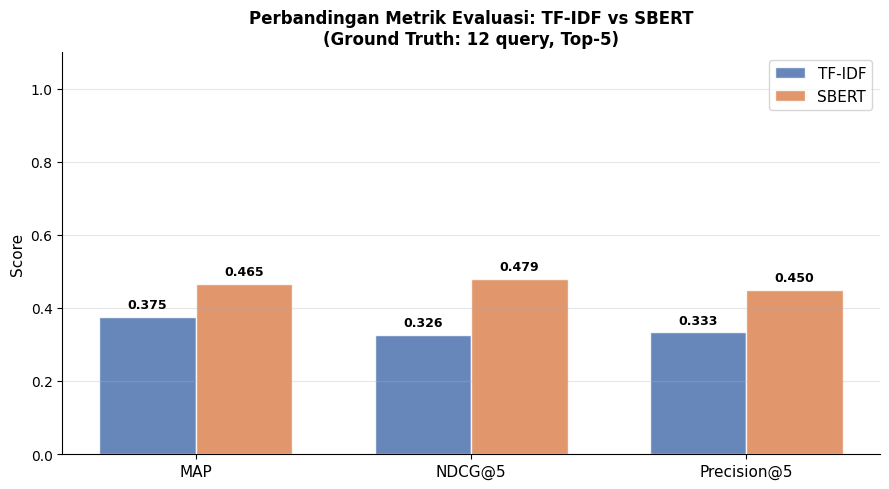

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.5  VISUALISASI PERBANDINGAN — MAP, NDCG, Precision@K
# ─────────────────────────────────────────────────────────────────────────────

metrics       = ["MAP", f"NDCG@{TOP_K}", f"Precision@{TOP_K}"]
tfidf_scores  = [eval_tfidf["map"], eval_tfidf["ndcg"], eval_tfidf["precision_k"]]
sbert_scores  = [eval_sbert["map"], eval_sbert["ndcg"], eval_sbert["precision_k"]]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, tfidf_scores, width, label="TF-IDF",
               color="#4C72B0", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + width/2, sbert_scores, width, label="SBERT",
               color="#DD8452", alpha=0.85, edgecolor="white")

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylabel("Score", fontsize=11)
ax.set_title("Perbandingan Metrik Evaluasi: TF-IDF vs SBERT\n"
             f"(Ground Truth: {len(GROUND_TRUTH)} query, Top-{TOP_K})",
             fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


### Visualisasi Per-Query

Line chart perbandingan Average Precision dan NDCG per query untuk melihat performa model secara detail.

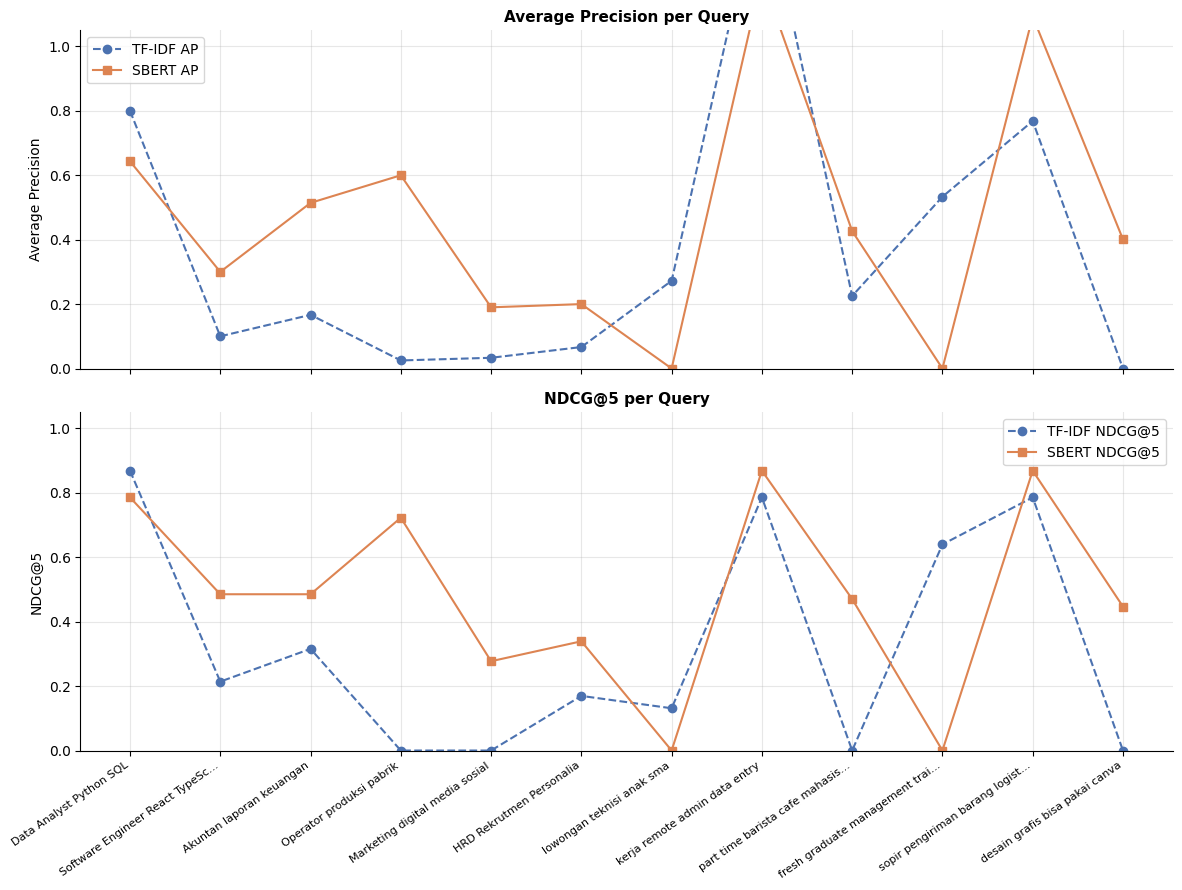

✅ Grafik per-query disimpan.


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.6  VISUALISASI PER-QUERY — NDCG & AP
# ─────────────────────────────────────────────────────────────────────────────

queries_short = [q[:30] + "..." if len(q) > 30 else q
                 for q in GROUND_TRUTH.keys()]

tfidf_ap   = [r["ap"]   for r in eval_tfidf["per_query"]]
sbert_ap   = [r["ap"]   for r in eval_sbert["per_query"]]
tfidf_ndcg = [r["ndcg"] for r in eval_tfidf["per_query"]]
sbert_ndcg = [r["ndcg"] for r in eval_sbert["per_query"]]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

idx = np.arange(len(queries_short))

# AP per query
ax1.plot(idx, tfidf_ap, "o--", color="#4C72B0", label="TF-IDF AP", linewidth=1.5, markersize=6)
ax1.plot(idx, sbert_ap, "s-",  color="#DD8452", label="SBERT AP",  linewidth=1.5, markersize=6)
ax1.set_ylabel("Average Precision", fontsize=10)
ax1.set_title("Average Precision per Query", fontsize=11, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(alpha=0.3)
ax1.spines[["top", "right"]].set_visible(False)

# NDCG per query
ax2.plot(idx, tfidf_ndcg, "o--", color="#4C72B0", label=f"TF-IDF NDCG@{TOP_K}", linewidth=1.5, markersize=6)
ax2.plot(idx, sbert_ndcg, "s-",  color="#DD8452", label=f"SBERT NDCG@{TOP_K}",  linewidth=1.5, markersize=6)
ax2.set_ylabel(f"NDCG@{TOP_K}", fontsize=10)
ax2.set_title(f"NDCG@{TOP_K} per Query", fontsize=11, fontweight="bold")
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(alpha=0.3)
ax2.spines[["top", "right"]].set_visible(False)

ax2.set_xticks(idx)
ax2.set_xticklabels(queries_short, rotation=35, ha="right", fontsize=8)

plt.tight_layout()
plt.show()
print("✅ Grafik per-query disimpan.")

### Tabel Ringkasan

Tabel perbandingan akhir metrik evaluasi kedua model untuk melihat model terbaik secara keseluruhan.

In [19]:
summary_df = pd.DataFrame([
    {
        "Model":          "TF-IDF (Vector Space)",
        "MAP":            round(eval_tfidf["map"], 4),
        f"NDCG@{TOP_K}":  round(eval_tfidf["ndcg"], 4),
        f"Precision@{TOP_K}": round(eval_tfidf["precision_k"], 4),
    },
    {
        "Model":          "SBERT (Semantic Search)",
        "MAP":            round(eval_sbert["map"], 4),
        f"NDCG@{TOP_K}":  round(eval_sbert["ndcg"], 4),
        f"Precision@{TOP_K}": round(eval_sbert["precision_k"], 4),
    },
])
summary_df = summary_df.set_index("Model")

print("\n" + "="*55)
print("  📊 TABEL RINGKASAN EVALUASI MODEL")
print("="*55)
print(summary_df.to_string())
print("="*55)

winner = "SBERT" if eval_sbert["map"] > eval_tfidf["map"] else "TF-IDF"
print(f"\n  🏆 Model terbaik berdasarkan MAP: {winner}")



  📊 TABEL RINGKASAN EVALUASI MODEL
                            MAP  NDCG@5  Precision@5
Model                                               
TF-IDF (Vector Space)    0.3754  0.3259       0.3333
SBERT (Semantic Search)  0.4654  0.4792       0.4500

  🏆 Model terbaik berdasarkan MAP: SBERT


## Step 7: Export — Simpan Index & Metadata

> - **`.faiss`** = Vector index yang dimuat saat server startup
> - **`.pkl`** = Metadata lowongan (title, company, dll) untuk ditampilkan ke user

### Ekspor Model SBERT

Menyimpan model SBERT ke disk agar dapat digunakan kembali tanpa download ulang saat startup backend.

In [20]:
local_model_path = '../data/retrieval/sbert_model_lokal'
import os
os.makedirs(local_model_path, exist_ok=True)
sbert_model.save(local_model_path)
print(f'💾 Model SBERT berhasil diekspor ke: {local_model_path}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Model SBERT berhasil diekspor ke: ../data/retrieval/sbert_model_lokal


## Step 8: Demo Search — Uji Cosine Similarity

> Simulasi bagaimana backend akan melakukan pencarian saat user mengetik di search bar.

### Demo Pencarian Interaktif

Membandingkan hasil pencarian TF-IDF vs SBERT untuk beberapa query nyata.

In [21]:
test_queries = [
    'lowongan teknisi anak sma',
    'kerja remote admin data entry',
    'part time barista cafe mahasiswa',
    'fresh graduate management trainee',
    'sopir pengiriman barang logistik',
]

for q in test_queries:
    print(f"\n🔍 Query: '{q}'")
    print("-" * 60)
    
    tfidf_res = search_tfidf(q, top_k=3)
    print("TF-IDF Results:")
    for i, r in enumerate(tfidf_res, 1):
        print(f"  {i}. [{r.get('similarity_score', 0):.3f}] {r.get('title', '')} @ {r.get('company_name', '')}")
        
    sbert_res = search_sbert(q, top_k=3)
    print("\nSBERT Results:")
    for i, r in enumerate(sbert_res, 1):
        print(f"  {i}. [{r.get('similarity_score', 0):.3f}] {r.get('title', '')} @ {r.get('company_name', '')}")
        
    print("=" * 60)



🔍 Query: 'lowongan teknisi anak sma'
------------------------------------------------------------
TF-IDF Results:
  1. [0.354] Guru Anak Berkebutuhan Khusus @ ASC Course
  2. [0.294] Part-time Nanny - Tanpa Ijazah, Palembang @ Sittercity
  3. [0.288] Loker Pengasuh, Samarinda (Jaga Anak - Lulusan SMA) @ Part-Time Sabtu Minggu

SBERT Results:
  1. [0.628] Tenaga Serabutan Gudang @ DSB Kids
  2. [0.622] Loker CONVEYOR PABRIK - Samarinda (Terdekat, Lulusan SMA) – 1.4+ Conv @ LTS Lohmann Therapie-Systeme AG
  3. [0.600] Loker TECHNICAL OPERATOR 8.3 hrs/day (Lulusan SMA), Pontianak @ Sectech Solutions

🔍 Query: 'kerja remote admin data entry'
------------------------------------------------------------
TF-IDF Results:
  1. [0.360] Data Entry Part Time Weekend Jobs (Work From Home Remote) di Indonesia @ Houston Skilled Consultancy
  2. [0.350] Lowongan kerja Entry Level Data Online WFH untuk Ibu Rumah Tangga di Indonesia @ Part-Time Sabtu Minggu
  3. [0.321] Loker online Medan data entry re